# AnnotationAgent — Задание 3
## Авторазметка | Sentiment Analysis

Анализ качества авторазметки выполненной AnnotationAgent.
Входные данные: `data/raw/collected_clean.parquet` (1867 записей)

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/labeled/collected_labeled.parquet")
print(f"Загружено: {df.shape[0]} записей")
print(f"Колонки: {list(df.columns)}")
df.head(3)

Загружено: 1867 записей
Колонки: ['text', 'label', 'source', 'collected_at', 'auto_label', 'confidence']


,text,label,source,collected_at,auto_label,confidence
0,"Dumb is as dumb does, in this thoroughly unint...",negative,hf:imdb,2026-03-26T03:53:17.341557,negative,0.95
1,I dug out from my garage some old musicals and...,positive,hf:imdb,2026-03-26T03:53:17.341557,positive,0.92
2,After watching this movie I was honestly disap...,negative,hf:imdb,2026-03-26T03:53:17.341557,negative,0.85


## 1. Распределение меток и уверенность

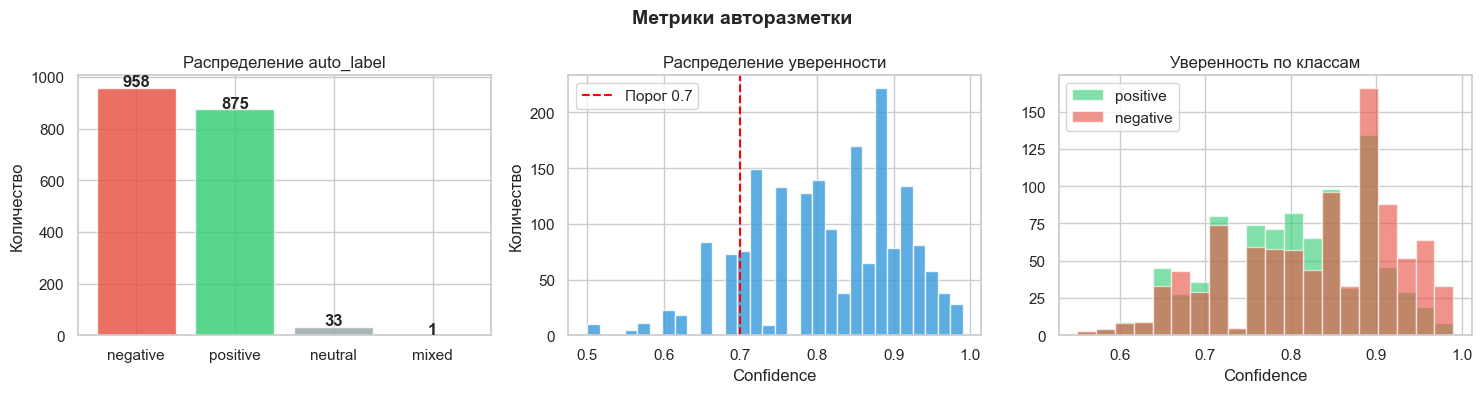

Средняя уверенность: 0.813
Флагов для проверки (< 0.7): 225


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Распределение auto_label
label_counts = df["auto_label"].value_counts()
axes[0].bar(label_counts.index, label_counts.values,
            color=["#e74c3c", "#2ecc71", "#95a5a6", "#3498db"], alpha=0.8)
axes[0].set_title("Распределение auto_label")
axes[0].set_ylabel("Количество")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Распределение уверенности
axes[1].hist(df["confidence"], bins=30, color="#3498db", alpha=0.8, edgecolor="white")
axes[1].axvline(x=0.7, color="red", linestyle="--", label="Порог 0.7")
axes[1].set_title("Распределение уверенности")
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Количество")
axes[1].legend()

# Уверенность по классам
df_binary = df[df["auto_label"].isin(["positive", "negative"])]
for label, color in [("positive", "#2ecc71"), ("negative", "#e74c3c")]:
    subset = df_binary[df_binary["auto_label"] == label]["confidence"]
    axes[2].hist(subset, bins=20, alpha=0.6, label=label, color=color)
axes[2].set_title("Уверенность по классам")
axes[2].set_xlabel("Confidence")
axes[2].legend()

plt.suptitle("Метрики авторазметки", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/annotation_metrics.png", dpi=150)
plt.show()

print(f"Средняя уверенность: {df['confidence'].mean():.3f}")
print(f"Флагов для проверки (< 0.7): {(df['confidence'] < 0.7).sum()}")

## 2. Cohen's κ — согласие авторазметки с оригинальными метками

Cohen's κ = 0.809
% Agreement = 90.5%

Интерпретация κ:
  0.0–0.2 — слабое согласие
  0.2–0.4 — удовлетворительное
  0.4–0.6 — умеренное
  0.6–0.8 — хорошее
  0.8–1.0 — отличное  ← наш результат


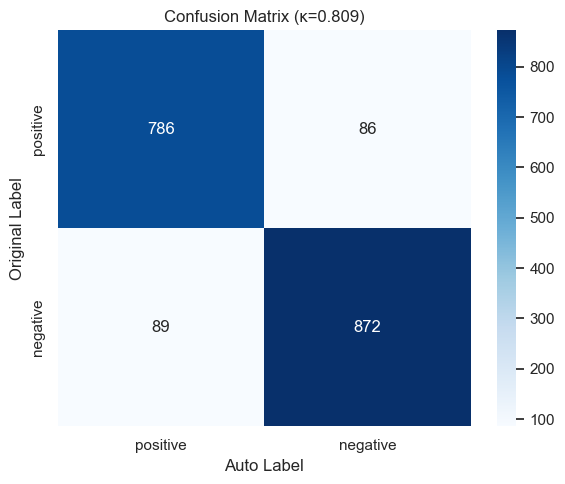

In [3]:
valid = df[df["auto_label"].isin(["positive", "negative"])].copy()
kappa = cohen_kappa_score(valid["label"], valid["auto_label"])
agreement_pct = (valid["label"] == valid["auto_label"]).mean() * 100

print(f"Cohen's κ = {kappa:.3f}")
print(f"% Agreement = {agreement_pct:.1f}%")
print(f"\nИнтерпретация κ:")
print(f"  0.0–0.2 — слабое согласие")
print(f"  0.2–0.4 — удовлетворительное")
print(f"  0.4–0.6 — умеренное")
print(f"  0.6–0.8 — хорошее")
print(f"  0.8–1.0 — отличное  ← наш результат" if kappa >= 0.8 else f"  0.6–0.8 — хорошее  ← наш результат")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(valid["label"], valid["auto_label"], labels=["positive", "negative"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["positive", "negative"],
            yticklabels=["positive", "negative"], ax=ax)
ax.set_title(f"Confusion Matrix (κ={kappa:.3f})")
ax.set_xlabel("Auto Label")
ax.set_ylabel("Original Label")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png", dpi=150)
plt.show()

## 3. Human-in-the-loop — примеры с низкой уверенностью (бонус)

In [4]:
review = pd.read_csv("../review_queue.csv")
print(f"Примеров для ручной проверки: {len(review)}")
print(f"Это {len(review)/len(df)*100:.1f}% от всего датасета\n")
print("Примеры с низкой уверенностью:")
review[["text", "auto_label", "confidence"]].head(5).assign(
    text=lambda x: x["text"].str[:100] + "..."
)

Примеров для ручной проверки: 225
Это 12.1% от всего датасета

Примеры с низкой уверенностью:


,text,auto_label,confidence
0,The only reason I watched this film was becaus...,negative,0.68
1,**** = A masterpiece to be recorded in the boo...,negative,0.60
2,This sci-fi adventure is not the best and by n...,negative,0.65
3,In Holland a gay writer Gerard (Jeroen Krabbe)...,positive,0.65
4,"Whether it's a good movie or not, films of thi...",positive,0.60
